# Chicago Geotweets

This notebook filters geo-located tweets from the Harvard CGA dataset according to specific spatial, temporal, and account bounds:
- **Time Window**: January 1, 2015 00:00:00 UTC through December 31, 2016 23:59:59 UTC (inclusive)
- **Geographic Bounding Box**:
  - Latitude: `40.73` to `43.21`
  - Longitude: `-89.42` to `-86.48`
- **Retained Fields**: All 24 fields in the archive schema (`message_id`, `tweet_date`, `tweet_text`, `tags`, `tweet_lang`, `source`, `place`, `retweets`, `tweet_favorites`, `photo_url`, `quoted_status_id`, `user_id`, `user_name`, `user_location`, `followers`, `friends`, `user_favorites`, `status`, `user_lang`, `latitude`, `longitude`, `data_source`, `gps`, and `spatialerror`).
- **Bot Account Filtering**: Excludes automated accounts identified using case-insensitive matching on `user_name`.

# 1. Import Dependencies

In [1]:
# Import os module for interacting with the operating system and managing file paths
import os

# Import re module for regular expression pattern matching in filenames
import re

# Import gzip module for reading compressed .gz data files directly
import gzip

# Import glob module for recursive file path pattern searching
import glob

# Import tempfile module for creating temporary directories during testing
import tempfile

# Import pandas library for data manipulation and tabular data processing
import pandas as pd

# Import numpy library for handling mathematical operations and missing values
import numpy as np

# Import Pool and cpu_count for parallel multi-core processing execution
from multiprocessing import Pool, cpu_count

# Import tqdm for displaying interactive progress bars during processing
from tqdm import tqdm

# Print confirmation message that environment and dependencies loaded correctly
print(" All required libraries and modules successfully imported.")

 All required libraries and modules successfully imported.


# 2. Parameters & Setup

In [2]:
# -------------------------------------------------------------
# 1. Temporal Range: 2010 to 2023 (inclusive)
# -------------------------------------------------------------
START_DATE = pd.to_datetime("2010-01-01 00:00:00")
END_DATE   = pd.to_datetime("2023-12-31 23:59:59")
TARGET_YEARS = [str(year) for year in range(2010, 2024)]

# -------------------------------------------------------------
# 2. Geographic Bounding Boxes: (min_lon, min_lat, max_lon, max_lat)
# -------------------------------------------------------------
REGIONS = {
    'israel': (34.2654333839, 29.5013261988, 35.8363969256, 33.2774264593),
    'china': (73.6753792663, 18.197700914, 135.026311477, 53.4588044297),
    'hong_kong': (113.8259, 22.1532, 114.4071, 22.5619)
}

# -------------------------------------------------------------
# 3. Output Schema & Directories
# -------------------------------------------------------------
RETAINED_FIELDS = ['message_id', 'latitude', 'longitude']

# Directories and Multiprocessing Config
RAW_DATA_DIR = "/n/holylabs/LABS/cga/Lab/data/geo-tweets/cga-sbg-tweets/"
OUTPUT_DIR = "/n/home10/jrochatrindade/Israel/data"
CORES = min(20, cpu_count() or 1)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration Constants Successfully Loaded:")
print(f"   • Temporal Window: {START_DATE} to {END_DATE}")
print(f"   • Target Regions: {list(REGIONS.keys())}")
print(f"   • Retained Columns: {RETAINED_FIELDS}")
print(f"   • Allocated CPU Workers: {CORES}")
print(f"   • Output Directory: {OUTPUT_DIR}")

Configuration Constants Successfully Loaded:
   • Temporal Window: 2010-01-01 00:00:00 to 2023-12-31 23:59:59
   • Target Regions: ['israel', 'china', 'hong_kong']
   • Retained Columns: ['message_id', 'latitude', 'longitude']
   • Allocated CPU Workers: 20
   • Output Directory: /n/home10/jrochatrindade/Israel/data


# 3. Core Functions Definition

In [3]:
def should_process_file(file_path):
    """Checks filename pattern (YYYY_MM_DD_HH.csv.gz) to include only 2010 to 2023."""
    basename = os.path.basename(file_path)
    match = re.search(r"(\d{4})_(\d{2})_(\d{2})", basename)
    if match:
        year = int(match.group(1))
        return 2010 <= year <= 2023
    return True


def process_file(file_path):
    """
    Ingests a single tweet file and splits records into separate
    DataFrames by geographic region without text/bot filtering.
    """
    empty_result = {region: pd.DataFrame() for region in REGIONS}
    try:
        if not should_process_file(file_path):
            return empty_result

        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f, sep='\t', on_bad_lines="skip", dtype=str)

        # Handle column naming variations for date
        if 'tweet_date' not in df.columns and 'date' in df.columns:
            df['tweet_date'] = df['date']
        elif 'tweet_date' in df.columns and 'date' in df.columns:
            df['tweet_date'] = df['tweet_date'].fillna(df['date'])

        # Check required columns
        required_cols = ['message_id', 'tweet_date', 'latitude', 'longitude']
        if not all(col in df.columns for col in required_cols):
            return empty_result

        # Convert coordinates and date to numeric / datetime
        df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
        df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
        df['parsed_date'] = pd.to_datetime(df['tweet_date'], errors='coerce')

        # Drop rows missing coordinates, date, or message_id
        df = df.dropna(subset=['message_id', 'parsed_date', 'latitude', 'longitude'])

        # Filter temporal range (2010 - 2023)
        date_mask = (df['parsed_date'] >= START_DATE) & (df['parsed_date'] <= END_DATE)
        df = df[date_mask]

        if df.empty:
            return empty_result

        # Separate into each region's bounding box
        result = {}
        for region_name, (min_lon, min_lat, max_lon, max_lat) in REGIONS.items():
            spatial_mask = (
                (df['latitude'] >= min_lat) & (df['latitude'] <= max_lat) &
                (df['longitude'] >= min_lon) & (df['longitude'] <= max_lon)
            )
            filtered = df[spatial_mask].copy()

            if not filtered.empty:
                # Cast to requested types: message_id BIGINT (int64), lat/lon FLOAT (float64)
                filtered['message_id'] = pd.to_numeric(filtered['message_id'], errors='coerce').astype('Int64')
                filtered['latitude']   = filtered['latitude'].astype('float64')
                filtered['longitude']  = filtered['longitude'].astype('float64')

                filtered = filtered.dropna(subset=['message_id'])
                result[region_name] = filtered[RETAINED_FIELDS]
            else:
                result[region_name] = pd.DataFrame()

        return result

    except Exception:
        return empty_result

# 4. Verification & Unit Tests

In [4]:
print(" Running self-testing verification suite on mock dataset...")

# Create mock dataset entries representing scenarios across target regions
mock_data = [
    # 1. Valid Israel record (within date & bounding box)
    {"message_id": "1001", "date": "2010-05-10 12:00:00", "latitude": 31.7683, "longitude": 35.2137},
    # 2. Valid China record (within date & bounding box)
    {"message_id": "2002", "date": "2018-08-15 08:30:00", "latitude": 39.9042, "longitude": 116.4074},
    # 3. Valid Hong Kong record (within date & bounding box)
    {"message_id": "3003", "date": "2023-12-31 23:59:59", "latitude": 22.3193, "longitude": 114.1694},
    # 4. Out of date bounds (too early: 2009)
    {"message_id": "4004", "date": "2009-12-31 23:59:59", "latitude": 31.7683, "longitude": 35.2137},
    # 5. Out of spatial bounds (Chicago - should not match any region)
    {"message_id": "5005", "date": "2015-06-15 12:00:00", "latitude": 41.8781, "longitude": -87.6298},
    # 6. Missing coordinates (should be dropped)
    {"message_id": "6006", "date": "2020-01-01 10:00:00", "latitude": None, "longitude": None}
]

df_mock = pd.DataFrame(mock_data)

with tempfile.TemporaryDirectory() as tmp_dir:
    # Use a filename matching the 2010-2023 filter pattern
    test_file = os.path.join(tmp_dir, "2015_01_01_00.csv.gz")
    with gzip.open(test_file, 'wt', encoding='utf-8') as f:
        df_mock.to_csv(f, sep='\t', index=False)
        
    test_res = process_file(test_file)

    # 1. Verify that all expected regions exist in the returned dictionary
    assert set(test_res.keys()) == set(REGIONS.keys()), f"Missing regions in result keys: {test_res.keys()}"

    # 2. Verify expected IDs per region
    israel_ids = set(test_res['israel']['message_id'].astype(str).tolist())
    china_ids = set(test_res['china']['message_id'].astype(str).tolist())
    hk_ids = set(test_res['hong_kong']['message_id'].astype(str).tolist())

    assert israel_ids == {"1001"}, f"Israel mismatch. Expected {{'1001'}}, got {israel_ids}"
    # Note: Hong Kong coordinates physically fall within China's broader bounding box
    assert "2002" in china_ids and "3003" in china_ids, f"China mismatch. Expected {{'2002', '3003'}} in China, got {china_ids}"
    assert hk_ids == {"3003"}, f"Hong Kong mismatch. Expected {{'3003'}}, got {hk_ids}"

    # 3. Verify schema and data types for each non-empty DataFrame
    for region_name, df_region in test_res.items():
        if not df_region.empty:
            assert list(df_region.columns) == RETAINED_FIELDS, f"Schema mismatch for {region_name}: {list(df_region.columns)}"
            assert pd.api.types.is_integer_dtype(df_region['message_id']), f"message_id in {region_name} must be integer"
            assert pd.api.types.is_float_dtype(df_region['latitude']), f"latitude in {region_name} must be float"
            assert pd.api.types.is_float_dtype(df_region['longitude']), f"longitude in {region_name} must be float"

print("ALL UNIT TESTS PASSED SUCCESSFULLY!")

 Running self-testing verification suite on mock dataset...
ALL UNIT TESTS PASSED SUCCESSFULLY!


# 5. Pre-filtering

In [5]:
print("Discovering raw dataset files in repository for years 2010-2023...")

all_files = []
for year in TARGET_YEARS:
    year_path = os.path.join(RAW_DATA_DIR, year, "**", "*.csv.gz")
    found_files = glob.glob(year_path, recursive=True)
    all_files.extend(found_files)
    if found_files:
        print(f"   • Year {year}: Found {len(found_files):,} files.")

total_files = len(all_files)
filtered_files = [f for f in all_files if should_process_file(f)]

print(f"\nTotal raw archive files discovered: {total_files:,}")
print(f"Files queued for processing: {len(filtered_files):,}")

Discovering raw dataset files in repository for years 2010-2023...
   • Year 2010: Found 79 files.
   • Year 2011: Found 1,172 files.
   • Year 2012: Found 7,038 files.
   • Year 2013: Found 7,888 files.
   • Year 2014: Found 8,753 files.
   • Year 2015: Found 8,760 files.
   • Year 2016: Found 8,784 files.
   • Year 2017: Found 8,760 files.
   • Year 2018: Found 8,760 files.
   • Year 2019: Found 8,759 files.
   • Year 2020: Found 8,557 files.
   • Year 2021: Found 8,451 files.
   • Year 2022: Found 8,504 files.
   • Year 2023: Found 4,319 files.

Total raw archive files discovered: 98,584
Files queued for processing: 98,584


# 6. Parallel Multiprocessing Data Execution

In [6]:
print(f"Processing {len(filtered_files):,} files using {CORES} multiprocessing workers...")

# Initialize accumulators for each region
region_results = {region: [] for region in REGIONS}

with Pool(processes=CORES) as pool:
    for file_output in tqdm(pool.imap_unordered(process_file, filtered_files), 
                            total=len(filtered_files), 
                            desc="Filtering Tweets"):
        for region_name, df_chunk in file_output.items():
            if not df_chunk.empty:
                region_results[region_name].append(df_chunk)

for region_name, chunks in region_results.items():
    print(f"   • {region_name.capitalize()}: {len(chunks):,} non-empty chunks collected.")

Processing 98,584 files using 20 multiprocessing workers...


Filtering Tweets: 100%|██████████| 98584/98584 [2:01:30<00:00, 13.52it/s]  

   • Israel: 88,771 non-empty chunks collected.
   • China: 94,010 non-empty chunks collected.
   • Hong_kong: 87,590 non-empty chunks collected.


# 7. Dataset Merging & Exporting

In [9]:
exported_dataframes = {}

for region_name, chunks in region_results.items():
    print(f"\nProcessing export for: {region_name.upper()}...")
    
    if chunks:
        final_df = pd.concat(chunks, ignore_index=True)
        
        # Enforce exact target data types
        final_df['message_id'] = final_df['message_id'].astype('int64')
        final_df['latitude']   = final_df['latitude'].astype('float64')
        final_df['longitude']  = final_df['longitude'].astype('float64')
        
        output_file = os.path.join(OUTPUT_DIR, f"filtered_tweets_{region_name}_2010_2023.csv.gz")
        print(f"Saving compressed file to: {output_file}...")
        
        final_df.to_csv(output_file, index=False, sep='\t', compression='gzip')
        print(f"SUCCESS! Exported {len(final_df):,} tweets for {region_name}.")
        display(final_df.head(3))
        
        exported_dataframes[region_name] = final_df
    else:
        print(f"No tweets found for {region_name}. Output file was not created.")
        exported_dataframes[region_name] = pd.DataFrame(columns=RETAINED_FIELDS)


Processing export for: ISRAEL...
Saving compressed file to: /n/home10/jrochatrindade/Israel/data/filtered_tweets_israel_2010_2023.csv.gz...
SUCCESS! Exported 19,128,760 tweets for israel.


,message_id,latitude,longitude
0,139376910428930048,32.778257,35.039450
1,108155670917955584,31.797155,34.705103
2,114059732842594304,31.994465,34.871393



Processing export for: CHINA...
Saving compressed file to: /n/home10/jrochatrindade/Israel/data/filtered_tweets_china_2010_2023.csv.gz...
SUCCESS! Exported 346,482,813 tweets for china.


,message_id,latitude,longitude
0,3370525258682368,30.238900,120.145283
1,18870745048289280,37.489996,126.737024
2,13789059738505216,37.610594,126.955799



Processing export for: HONG_KONG...
Saving compressed file to: /n/home10/jrochatrindade/Israel/data/filtered_tweets_hong_kong_2010_2023.csv.gz...
SUCCESS! Exported 6,408,418 tweets for hong_kong.


,message_id,latitude,longitude
0,262355657171300352,22.419263,114.223846
1,262356634473463808,22.293665,114.239660
2,262323486851223552,22.299582,114.167058


# 8. Spatial Diagnostic Plot

Generating static spatial coverage plot for Israel...


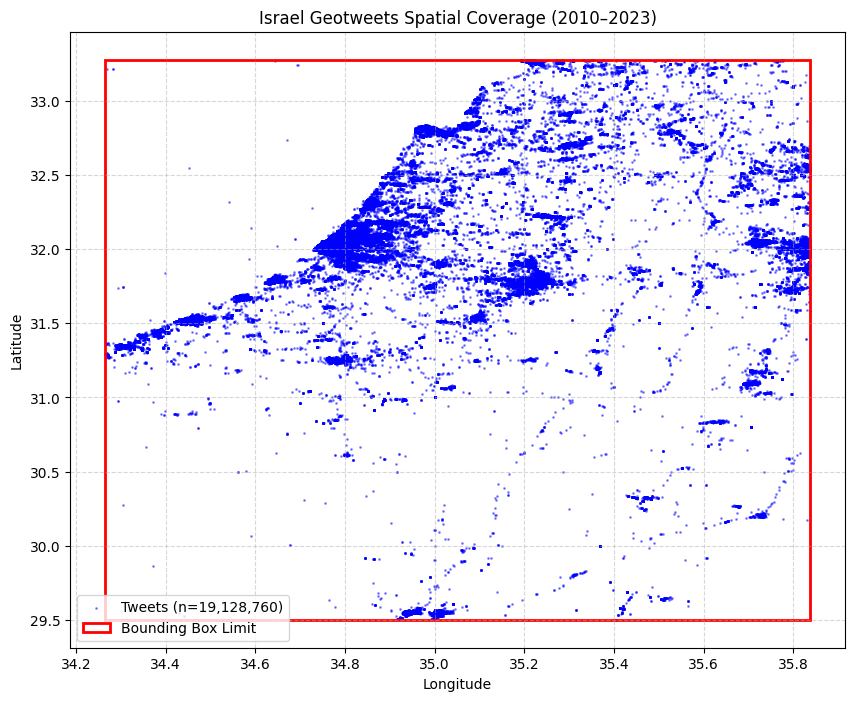

Saved plot to: /n/home10/jrochatrindade/Israel/data/filtered_tweets_spatial_verification_israel.png

Generating static spatial coverage plot for China...


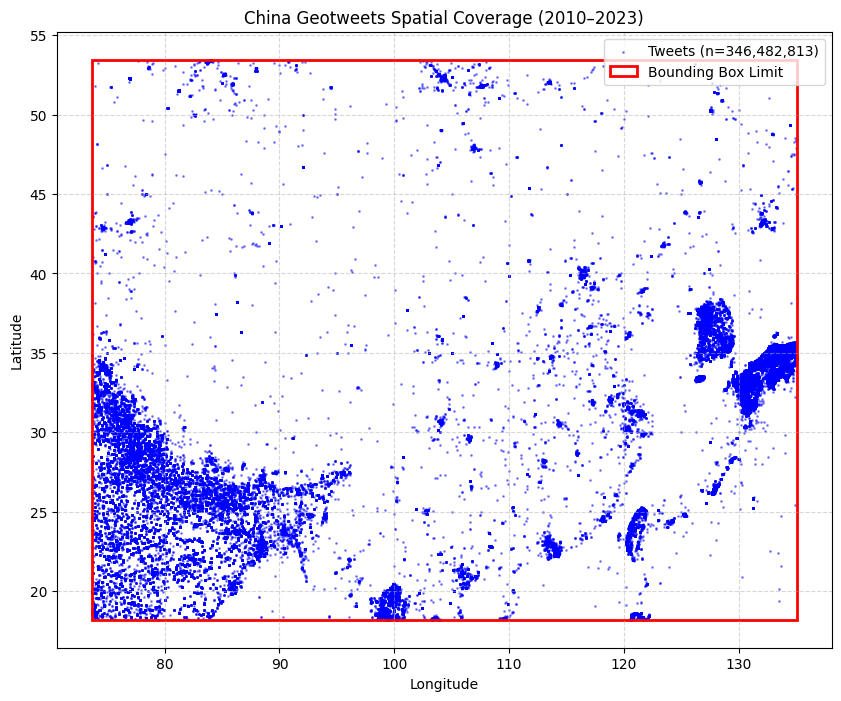

Saved plot to: /n/home10/jrochatrindade/Israel/data/filtered_tweets_spatial_verification_china.png

Generating static spatial coverage plot for Hong Kong...


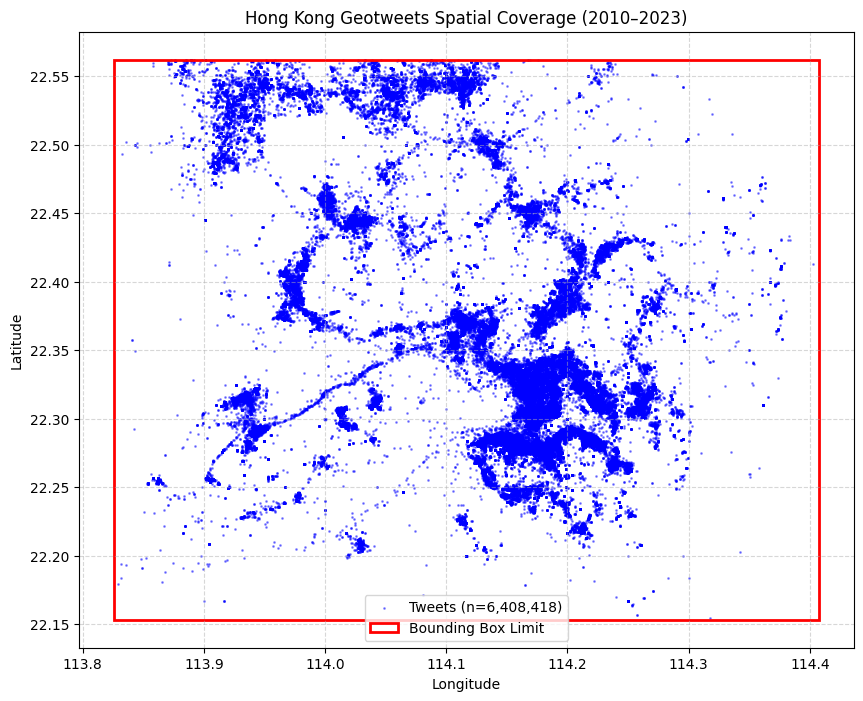

Saved plot to: /n/home10/jrochatrindade/Israel/data/filtered_tweets_spatial_verification_hong_kong.png



In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Iterate through each region and generate its diagnostic plot
for region_name, df_region in exported_dataframes.items():
    if not df_region.empty:
        display_name = region_name.replace("_", " ").title()
        print(f"Generating static spatial coverage plot for {display_name}...")
        
        # Unpack bounding box coordinates: (min_lon, min_lat, max_lon, max_lat)
        min_lon, min_lat, max_lon, max_lat = REGIONS[region_name]
        
        # Initialize figure canvas
        plt.figure(figsize=(10, 8))
        
        # Optional: downsample for plotting performance if dataset exceeds 500k rows
        plot_df = df_region.sample(n=min(len(df_region), 500_000), random_state=42) if len(df_region) > 500_000 else df_region
        
        # Scatter coordinates
        plt.scatter(
            plot_df['longitude'], 
            plot_df['latitude'], 
            c='blue', 
            alpha=0.4, 
            s=1, 
            label=f'Tweets (n={len(df_region):,})'
        )
        
        # Draw the target bounding box boundary
        rect = patches.Rectangle(
            (min_lon, min_lat), 
            max_lon - min_lon, 
            max_lat - min_lat,
            linewidth=2, 
            edgecolor='red', 
            facecolor='none', 
            label='Bounding Box Limit'
        )
        plt.gca().add_patch(rect)
        
        # Formatting
        plt.title(f'{display_name} Geotweets Spatial Coverage (2010–2023)')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='best')
        
        # Save individual region plot
        static_plot_path = os.path.join(OUTPUT_DIR, f"filtered_tweets_spatial_verification_{region_name}.png")
        plt.savefig(static_plot_path, dpi=300, bbox_inches='tight')
        
        # Display plot
        plt.show()
        print(f"Saved plot to: {static_plot_path}\n")
    else:
        print(f"DataFrame for {region_name.title()} is empty. Skipping plot generation.")